##### Load Required Libraries

In [1]:
#!/scratch/nnenv/bin/python3
#!~/hpc-share/nnenv/bin/python3
#!nvidia-smi

%pip install watermark numpy pandas matplotlib torch torchvision torchaudio | grep -v 'already satisfied'
%load_ext watermark
%watermark -v -p watermark,numpy,pandas,matplotlib,torch

#
import math,random,os,sys,copy,time,glob,itertools,shutil,re, json
from scipy.stats import wilcoxon

#
import numpy as np

#
import torch, gc
torch.cuda.empty_cache()
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

import torch.nn as nn
import torch.nn.functional as tf
from torch.utils.data import Dataset,DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor, Lambda

import pandas as pd

from pathlib import Path
sys.path[0] = str(Path(sys.path[0]).parent)

#
from demofcns import *
from opts.asgm.torchlasgm import PID
from opts.elpf.fo import LPF
from opts.elpf.esfo import esLPF

print("Is cuda available?", torch.cuda.is_available())
# python3 -m torch.utils.collect_env

Note: you may need to restart the kernel to use updated packages.
Python implementation: CPython
Python version       : 3.10.6
IPython version      : 8.9.0

watermark : 2.3.1
numpy     : 1.24.1
pandas    : 1.5.3
matplotlib: 3.6.3
torch     : 1.13.1+cu116

Is cuda available? True


##### Setup Configurations (Hyperparameters and so on)

In [2]:

# - is it being run remotely on OSU EECS server?
remotelyrun = 2 # 0 [local computer] | 1 [dalton gpu] | 2 [hpc cluster]

#----------------------
# Load setup config
#----------------------
with open('cfgs.json', 'r') as cfglist:
  cfgs = json.load(cfglist)
  
# setup
cfgs['storedir'] = "../expstore"

# - pick data-set
cfgs["dataset"] = "atoy"
# - set std. batchsize for each epoch, runs, epochs, multiprocessing, human
cfgs["batch-size"] = 128 # 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, ...
cfgs['runs'] = 10
cfgs["epochs"] = 10

# -pick computation device
devcnt = torch.cuda.device_count()

# random seed for python libraries
cfgs["seed"] = 2023
cfgs["var_seed"] = 1
worker_seed = cfgs["seed"] % (2**32)
cfgs["num-workers"] = 0 #3
cfgs["human_signature"] = "oas" # for signing experiments ran.

if devcnt > 1:
  cfgs["device"] = torch.device('cuda') # "cuda:1"
  torch.cuda.set_device(0)
elif devcnt == 1:
  cfgs["device"] = torch.device('cuda')
else:
  cfgs["device"] = torch.device('cpu')
#
if remotelyrun:
  cfgs["remote"] = True
else:
  cfgs["remote"] = False
  

##### (Generate) or Load the Dataset


In [3]:

#----------------------
# Download/Load Dataset
#----------------------
if not cfgs["remote"]:
  # same dir. as source-code
  data_folder = "../data"
  # result. storage dir
  cfgs['storedir'] = "../expstore"
else:
  if remotelyrun == 1:
    # dalton's scratch on OSU's eecs server
    data_folder = "/scratch/data"
    # result. storage dir
    cfgs['storedir'] = "/scratch/expstore"
  else:
    data_folder = "/nfs/stak/users/somefuno/hpc-share/data"    
    # result. storage dir
    cfgs['storedir'] = "/nfs/stak/users/somefuno/hpc-share/expstore"

# aToy
class aToy(Dataset):
    def __init__(self, data, split="", transform=None, target_transform=None):
      if split=="train": 
        self.data = data['train']
      elif split=="val" or split=="test":
        self.data = data['dev']
      #
      self.transform = transform
      self.target_transform = target_transform
      
      self.input = self.data['in']      
      self.labels = self.data['out']
        
            
    def __len__(self):
      return self.labels.shape[0]
    
    def __getitem__(self, idx):
        
      x = self.input[idx,:]
      y = self.labels[idx,]

      # transforms ...
      if self.transform:
        x = self.transform(x)
      if self.target_transform:
        y = self.target_transform(y)
          
        
      return x,y
    
def aToyGenerator(data_dir=f"{data_folder}/toydata_twofeatures_two_class.txt"):
  
  # Dataset with input: dim = 2 and ouput: class = binary, dim = 1 
  df = pd.read_csv(data_dir, sep="\t")
  # print(df.head())
  data_in = torch.tensor(df[["x1", "x2"]].values, dtype=torch.float)
  data_out = torch.tensor(df["label"].values, dtype=torch.int64)
  
  #
  torch.Generator().manual_seed(0)
  for i in range(10):
    data_in = torch.cat([data_in, data_in+torch.normal(0,0.1,size=(data_in.shape[0],1))])
    data_out = torch.cat([data_out,data_out])
    
  #
  intrain, inval = torch.utils.data.random_split(data_in, [int(0.6*data_in.shape[0]), int(0.4*data_in.shape[0])], generator=torch.Generator().manual_seed(0))
  # print(len(intrain.indices))
  
  atoy_data_train = {"in":data_in[intrain.indices,:], "out":data_out[intrain.indices,]}
  atoy_data_dev = {"in":data_in[inval.indices,:], "out":data_out[inval.indices,]}
  return {"train":atoy_data_train, "dev":atoy_data_dev}

if cfgs["dataset"] == "atoy":
  atoy_data = aToyGenerator()
  train_data = aToy(atoy_data,split="train")   
  test_data = aToy(atoy_data,split="test")  


##### Construct Model (Differentiable Function) with  necessary methods.

In [4]:
class thisNN(nn.Module):
  def __init__(self,num_heads=1,in_feats=1,out_feats=1, loss_type="mse", outs_class=False, mdl_name="nn1") -> None:
    """
    __init__ _summary_

    _extended_summary_

    Args:
        num_heads (int, req): net. output head. Defaults to 1.
        in_feats (int, req): net. input dimension. Defaults to 1.
        out_feats (int, req): net. output dimension per head. Defaults to 1.
        loss_type (str, req): type of loss function Defaults to "mse". ("mse","mce" for multi-class cross-entropy, "bce" binary-class cross-entropy)
        outs_class (bool, req): does model return class indices. Defaults to False, implying it outputs real-valued probabilities. This is also true for loss_type="mse" regardless of user-choice.
    """
    super().__init__()
    self.num_heads = num_heads
    
    # define mdl. params.
    self.linearfcn = nn.ModuleList()
    
    self.keylinear = nn.ModuleList()
    self.valuelinear = nn.ModuleList()
    self.multiheadattn  = nn.ModuleList()
    for _ in range(num_heads):
      self.keylinear.append(
        torch.nn.Linear(in_features=in_feats,out_features=in_feats, bias=True)
      )
      self.valuelinear.append(
        torch.nn.Linear(in_features=in_feats,out_features=in_feats, bias=True)
      )
      self.multiheadattn.append(
        torch.nn.MultiheadAttention(in_feats,1,batch_first=True,)
      )      
      self.linearfcn.append(
        torch.nn.Linear(in_features=in_feats,out_features=out_feats, bias=True)
      )

    self.relu = nn.ReLU()
    
    # prob.fcn at last output or network head layer
    if loss_type == "bce" or loss_type == "mse":
      self.out = torch.nn.Sigmoid()
    else:
      self.out = torch.nn.Softmax()
    
    self.loss_type = loss_type
    self.outs_class = outs_class
    
    # optimizer
    self.sgm = None
    
    # saved trained model
    self.chkpt = None
    
    
    self.devcnt = torch.cuda.device_count()
    self.device = None
    self.name = mdl_name
    
    if not(loss_type == "mse" or loss_type =="mce" or loss_type == "bce"):
      raise ValueError(f"loss_type='{loss_type}' is not defined for this class")
    if (loss_type == "mse"):
      self.outs_class = False    
    
@clsmethod(thisNN)
def forward(self:thisNN, x):
  # pre-process
  # x= x.unsqueeze(-1)
  # x = x.permute(0,2,1)
  logits = []
  for hid in range(self.num_heads):
    xq = x.unsqueeze(-1)
    xq = xq.permute(0,2,1)
    keylinear = self.keylinear[hid]
    valuelinear = self.valuelinear[hid]
    xk = xq + self.relu(keylinear(xq))
    xv = xq + self.relu(valuelinear(xq))
    
    multiheadattn = self.multiheadattn[hid]
    y,_ = multiheadattn(xq,xk,xv)
    y = y + self.relu(y)
    
    
    y = y.permute(0,2,1)
    y = y.squeeze(-1)
    linearfcn = self.linearfcn[hid]
    y = linearfcn(y)  
    logits.append(y)
    
  return logits # List [Tensor]

@clsmethod(thisNN)
def outhead(self:thisNN, x):
  probs = []
  for hid in range(self.num_heads):
    y = self.out(x[hid])
    probs.append(y)  
  return probs # List [Tensor]

# Add necessary functions to train model
add_to_thisnn(thisNN,worker_seed,setseed,cseedwk)


##### Run the Network Modeling (Training) 

In [5]:
# Test.

torch.manual_seed(2023)
devcnt = torch.cuda.device_count()

cfgs['mdl_name_dir'] = "nndemo1toy_show"
isclassifier = True
cfgs['p'] = 1
cfgs["ss_init"] = 1e-3
cfgs["eps_ss"] = 5e-1 # default 5e-1
cfgs["weight_decay"] = 1e-5 # default 1e-5
mdl = thisNN(num_heads=1,in_feats=2,out_feats=1,loss_type="bce",outs_class=isclassifier, mdl_name=cfgs['mdl_name_dir'])
if devcnt > 0:
    mdl.cuda()
cfgs['pathstr'] = str(mdl.name)+str(cfgs["batch-size"])+"_"+cfgs["dataset"]+"_"+str(cfgs["runs"])+"_"+str(cfgs["epochs"])

mdl.runs(train_data, test_data, cfgs=cfgs, eval_name="Test")

Seed: 2023
********************************************************************************************
total params, d=39
[p=1, eff. step-size [linear correlation est. (starting := 0.119954)]
aSGM info: (step-size ending := 0), step-size pole : 0.9928],
[LPF Poles [i,o] : 0.9, 1e-05]
********************************************************************************************

1: Elapsed Train time: 0.04-mins.
Batches/Steps/Iterations per Epoch:    96
Train:	[ Avg Loss: 0.0413, Accuracy: 98.86%, FA = 1.750442% ]  || Test: [ Avg Loss: 0.0034, Accuracy: 99.89%,  FA = 0.049838% ]
Elapsed Inf. time: 0.00-mins.
 
...[eff. step-size (starting := 0.113614)]...
2: Elapsed Train time: 0.03-mins.
Batches/Steps/Iterations per Epoch:    96
Train:	[ Avg Loss: 0.0049, Accuracy: 99.84%, FA = 0.208768% ]  || Test: [ Avg Loss: 0.0025, Accuracy: 99.90%,  FA = 0.124595% ]
Elapsed Inf. time: 0.00-mins.
 
...[eff. step-size (starting := 0.170446)]...
3: Elapsed Train time: 0.03-mins.
Batches/Steps/Iteratio

/nfs/stak/users/somefuno/hpc-share/nnenv/lib/python3.10/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


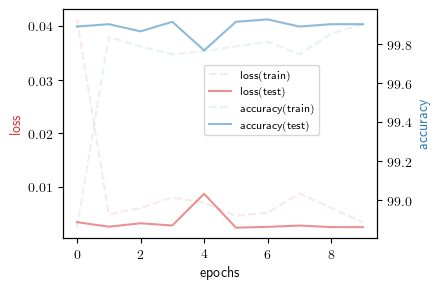

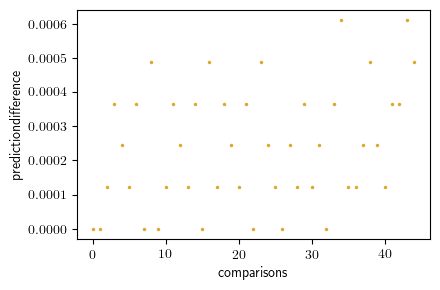

In [6]:
# Plots
plotter_v1(cfgs,run_idx=1)

Using the test (or development) dataset, the average prediction difference gives the average percent of the test (or development) dataset on which the trained network flips its decision.

Subtracting the average prediction difference from the average test-accuracy, 
recallibrates the expected test-accuracy from the trained model, we call this the effective test-accuracy.

Here, 10 statistical training runs leads to a combined 45 prediction comparisons, on which the prediction difference is computed. 